In [12]:
## tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [ ]:
# api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
# arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
# print(arxiv.name)

arxiv


In [13]:
import arxiv
from langchain_core.tools import tool

@tool
def arxiv_search(query: str, max_results: int = 2) -> str:
    """
    Search ArXiv for scientific papers and academic articles.
    Use this tool to find information about specific papers, machine learning research, 
    or physics/math publications.
    
    Args:
        query: The search keywords or paper title/ID (e.g., '1706.03762' or 'turboQuant paper').
        max_results: The maximum number of papers to return. Defaults to 5.
    """
    try:
        # 1. Initialize the ArXiv Search object
        search = arxiv.Search(
            query=query,
            max_results=max_results
        )
        
        # 2. Use the new Client API syntax to fetch results
        client = arxiv.Client()
        results = client.results(search)
        
        # 3. Format the output as a clean string for the LLM to digest
        formatted_results = []
        for paper in results:
            info = (
                f"Title: {paper.title}\n"
                f"Published: {paper.published.strftime('%Y-%m-%d')}\n"
                f"Authors: {', '.join([author.name for author in paper.authors])}\n"
                f"Summary: {paper.summary}\n"
                f"Link: {paper.entry_id}\n"
                f"{'-'*40}"
            )
            formatted_results.append(info)
            
        if not formatted_results:
            return f"No papers found on ArXiv matching query: '{query}'"
            
        return "\n".join(formatted_results)

    except Exception as e:
        return f"An error occurred while searching ArXiv: {str(e)}"


In [14]:
arxiv_search.invoke("turboQuant paper")

'Title: This paper has been withdrawn\nPublished: 2003-09-17\nAuthors: This paper has been withdrawn\nSummary:   This paper has been withdrawn\nLink: http://arxiv.org/abs/cond-mat/0309395v2\n----------------------------------------\nTitle: Revisiting RaBitQ and TurboQuant: A Symmetric Comparison of Methods, Theory, and Experiments\nPublished: 2026-04-21\nAuthors: Jianyang Gao, Yutong Gou, Yuexuan Xu, Jifan Shi, Yongyi Yang, Shuolin Li, Raymond Chi-Wing Wong, Cheng Long\nSummary: This technical note revisits the relationship between RaBitQ and TurboQuant under a unified comparison framework. We compare the two methods in terms of methodology, theoretical guarantees, and empirical performance, using a reproducible, transparent, and symmetric setup. Our results show that, despite the claimed advantage of TurboQuant, TurboQuant performs worse than RaBitQ in most tested settings of inner-product estimation, nearest-neighbor search and KV cache quantization. We further find that several repo

'Page: TurboQuant\nSummary: TurboQuant is an online vector quantization algorithm for compressing high-dimensional Euclidean vectors while preserving their geometric structure. It was proposed in 2025 by Amir Zandieh, Majid Daliri, Majid Hadian, and Vahab Mirrokni in the paper TurboQuant: Online Vector Quantization with Near-optimal Distortion Rate. The paper lists Zandieh and Mirrokni as affiliated with Google Research, Daliri with New York University, and Hadian with Google DeepMind. The method '

'Page: Attention Is All You Need\nSummary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the '


In [15]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [16]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [17]:
from langchain_community.tools import TavilySearchResults

tavily = TavilySearchResults() 

C:\Users\admin\AppData\Local\Temp\ipykernel_6208\1795806322.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [ ]:
tavily.invoke("Give me the recent AI news?")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': "Finance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n#### Machine Learning\n\n### Aviva deploys AI to stop £230M in sophisticated insurance fraud\n\nAI in Action\n\nJune 8, 2026\n\n### Google folds Display Ads into AI-first Demand Gen platform\n\nMarketing AI\n\nMay 27, 2026\n\n### IDC: How EMEA CIOs can jumpstart AI rollouts\n\nGovernance, Regulation & Policy\n\nApril 29, 2026\n\n#### Enterprise [...] April 29, 2026\n

In [18]:
tools = [arxiv_search, wiki, tavily]
tools

[StructuredTool(name='arxiv_search', description="Search ArXiv for scientific papers and academic articles.\nUse this tool to find information about specific papers, machine learning research, \nor physics/math publications.\n\nArgs:\n    query: The search keywords or paper title/ID (e.g., '1706.03762' or 'turboQuant paper').\n    max_results: The maximum number of papers to return. Defaults to 5.", args_schema=<class 'langchain_core.utils.pydantic.arxiv_search'>, func=<function arxiv_search at 0x0000012D08C94AE0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\admin\\Desktop\\Projects\\AI_ML_DATASCIENCE\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=500)),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]

In [19]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

c:\Users\admin\Desktop\Projects\AI_ML_DATASCIENCE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
llm.invoke("What is an AI?")

AIMessage(content='<think>\nOkay, so I need to explain what an AI is. Let me start by breaking down the term. AI stands for Artificial Intelligence, right? But what does that actually mean? From what I remember, it\'s about machines that can perform tasks that usually require human intelligence. But I\'m not entirely sure.\n\nFirst, maybe I should define AI in simple terms. Like, it\'s a system or machine that can think and learn. But wait, can machines really think? That\'s more of a philosophical question. Maybe I should stick to the technical definition. AI systems are designed to perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, understanding language, recognizing patterns, and so on.\n\nBut then there are different types of AI. I\'ve heard terms like narrow AI and general AI. Narrow AI is what we have today, which is designed for specific tasks. For example, voice assistants like Siri or Alexa are narrow AI because they\'r

In [20]:
llm_with_tools=llm.bind_tools(tools=tools)

In [21]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000012D29420B30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000012D294BA390>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv_search', 'description': "Search ArXiv for scientific papers and academic articles.\nUse this tool to find information about specific pape

In [22]:
llm_with_tools.invoke("What is the recent news on AI?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news on AI. I need to figure out which tool to use here. Let me check the available tools.\n\nFirst, there\'s arxiv_search, which is for scientific papers. But the user is asking about news, not research papers. So maybe not the best fit. Then there\'s wikipedia, but Wikipedia is more for general knowledge and facts, not the latest news. The third option is tavily_search_results_json, which is described as a search engine for comprehensive and current events. That sounds right because the user wants recent news. \n\nSo I should use tavily_search_results_json. The parameter required is a query. The user\'s query is "recent news on AI", so I\'ll structure the tool call with that. Let me make sure the syntax is correct. The function name is tavily_search_results_json, and the argument is {"query": "recent news on AI"}. \n\nI need to present this in the specified XML format. Let me double-che

In [ ]:
llm_with_tools.invoke("Provide me the details of the research paper Attention is All you need.")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for details about the research paper "Attention is All You Need." Let me think about how to approach this.\n\nFirst, I know that this paper is a seminal work in the field of natural language processing, introducing the Transformer model. The authors are likely to be key researchers in the area. But to get the exact details, I need to use the arXiv function since that\'s where such papers are typically published.\n\nThe title is "Attention is All You Need," so the arXiv query should use that exact title. I should make sure the search query is precise. The parameters for the arXiv function require a query string. I\'ll input the title as the query. \n\nI should check if there are any other parameters needed, but according to the tool description, only the query is required. The function will handle the rest. So I\'ll construct the tool call with the name "arxiv" and the arguments including the query a

## Workflow using Langgraph


In [23]:
# State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ## Human or AI message
from typing import Annotated ## labelling
from langgraph.graph.message import add_messages ## Reducers in Langgraph

In [24]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [25]:
# Entire Chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [26]:
# Node definition 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools_condtion routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

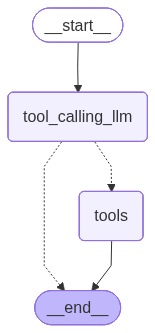

In [27]:
graph = builder.compile()
graph

In [28]:
messages=graph.invoke({"messages":"2601.01743"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

2601.01743
================================== Ai Message ==================================
Tool Calls:
  arxiv_search (75p9h12d5)
 Call ID: 75p9h12d5
  Args:
    max_results: 1
    query: 2601.01743
================================= Tool Message =================================
Name: arxiv_search

Title: AI Agent Systems: Architectures, Applications, and Evaluation
Published: 2026-01-05
Authors: Bin Xu
Summary: AI agents -- systems that combine foundation models with reasoning, planning, memory, and tool use -- are rapidly becoming a practical interface between natural-language intent and real-world computation. This survey synthesizes the emerging landscape of AI agent architectures across: (i) deliberation and reasoning (e.g., chain-of-thought-style decomposition, self-reflection and verification, and constraint-aware decision making), (ii) planning and control (from reactive policies to hierarchical 

In [29]:
messages=graph.invoke({"messages":"Hi, My name is Vraj."})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, My name is Vraj.
================================== Ai Message ==================================

Hello, Vraj! How can I assist you today?


In [30]:
messages=graph.invoke({"messages":"What are the latest news in india today?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What are the latest news in india today?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (27d7cmk15)
 Call ID: 27d7cmk15
  Args:
    query: latest news in India today
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest News Today, Breaking News, India News, Top Headlines | The Indian Express", "url": "https://indianexpress.com", "content": "### BJP alleges irregularities in Bengaluru waste tender, urges Governor to order probe\n\nAshoka BJP\n\n#### Tejas Mk-1A programme: HAL files case against supplier over 199 fake test reports\n\n#### Rs 1,300-crore flyover plan faces Bengaluru residents' flak over cost, traffic concerns\n\n#### 9 arrested, minor apprehended in Karnataka gang rape case after assault videos surface\n\n#### Know Your City: Inside Benga

## ReAct Framework

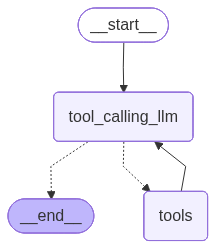

In [32]:
# Node definition 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools_condtion routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tools", END)

graph=builder.compile()
graph

In [33]:
messages=graph.invoke({"messages":"What are the recent news in AI and then tell me the recent research paper in AI Agents?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What are the recent news in AI and then tell me the recent research paper in AI Agents?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (ge0bdd9dk)
 Call ID: ge0bdd9dk
  Args:
    query: recent news in AI 2024
  arxiv_search (2kxpa0krq)
 Call ID: 2kxpa0krq
  Args:
    max_results: 5
    query: AI Agents
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI Pulse: Top AI Trends from 2024 - A Look Back | Trend Micro (US)", "url": "https://www.trendmicro.com/en_us/research/25/a/top-ai-trends-from-2024-review.html", "content": "figure-01\n\n‘Smallifying’ AI modelsHand in hand with the shift to agentic AI is the need for smaller, nimbler, faster models purpose-built for specific tasks. Again, lots of work went into this in 2024. In October, Meta released updates 